In [3]:
import os
new_dir = "/home/jingqi/RNALocateV3.0"
os.chdir(new_dir)
os.getcwd()

'/home/jingqi/RNALocateV3.0'

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from mpl_toolkits.mplot3d import Axes3D

## Correlation Calculation

### Pearson Coefficient

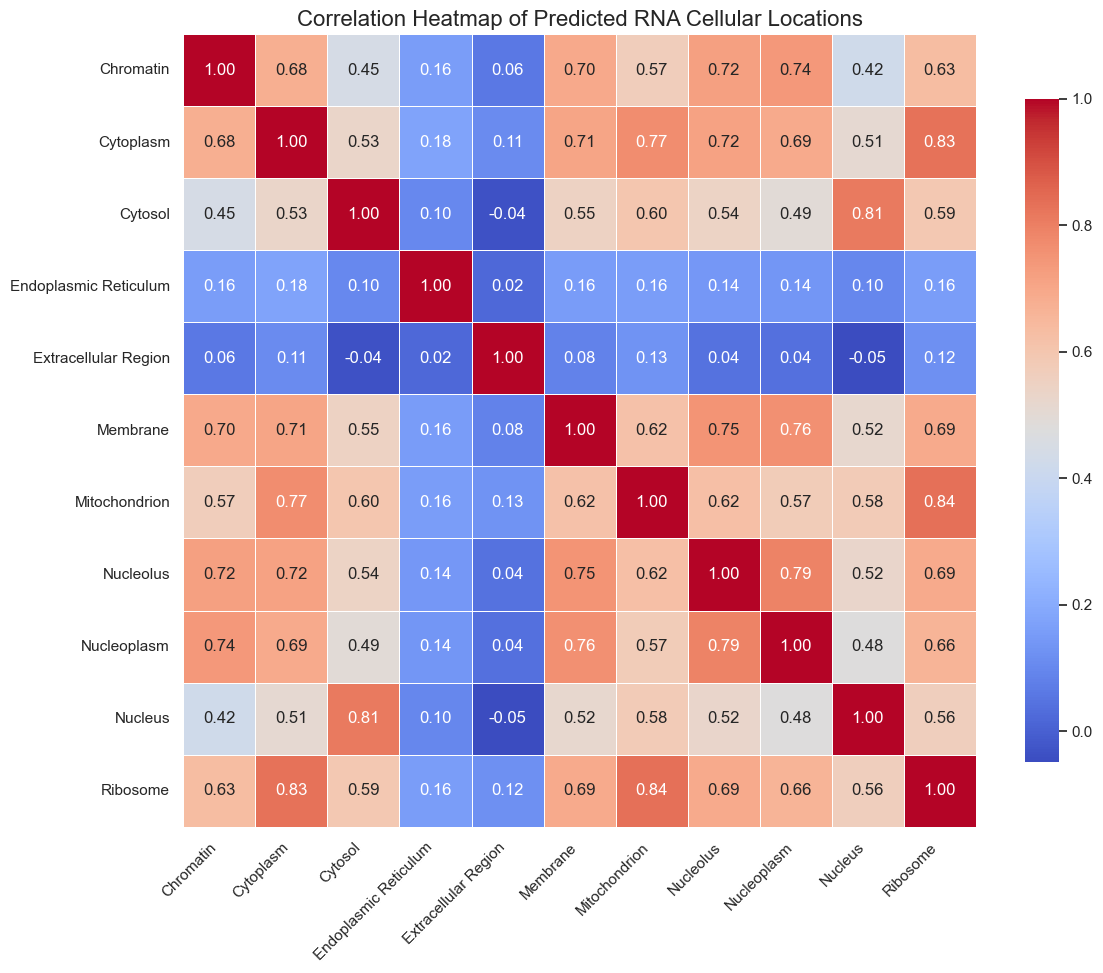

In [6]:
file_path = 'Data/Main/Probabilities.csv'
df = pd.read_csv(file_path)

# Identify the probability columns
prob_cols = [col for col in df.columns if col.endswith('_prob')]
prob_df = df[prob_cols]

# Clean column names for a better-looking plot
clean_names = [col.replace('_prob', '').replace('_', ' ').title() for col in prob_cols]
prob_df.columns = clean_names

# Calculate the Pearson correlation matrix
corr_matrix = prob_df.corr()

# Generate the Heatmap
plt.figure(figsize=(12, 10))
sns.set_theme(style="white")

# Create the heatmap
heatmap = sns.heatmap(
    corr_matrix, 
    annot=True,           # Show the correlation values in the cells
    cmap='coolwarm',      # Red-blue diverging color palette
    fmt=".2f",            # Format to 2 decimal places
    linewidths=0.5,       # Add lines between cells
    square=True,          # Make cells square
    cbar_kws={"shrink": .8}
)

plt.title('Correlation Heatmap of Predicted RNA Cellular Locations', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Display the plot
plt.show()

# Optional: Save the correlation matrix to a CSV file
# corr_matrix.to_csv('location_correlations.csv')

### Cosine similarity

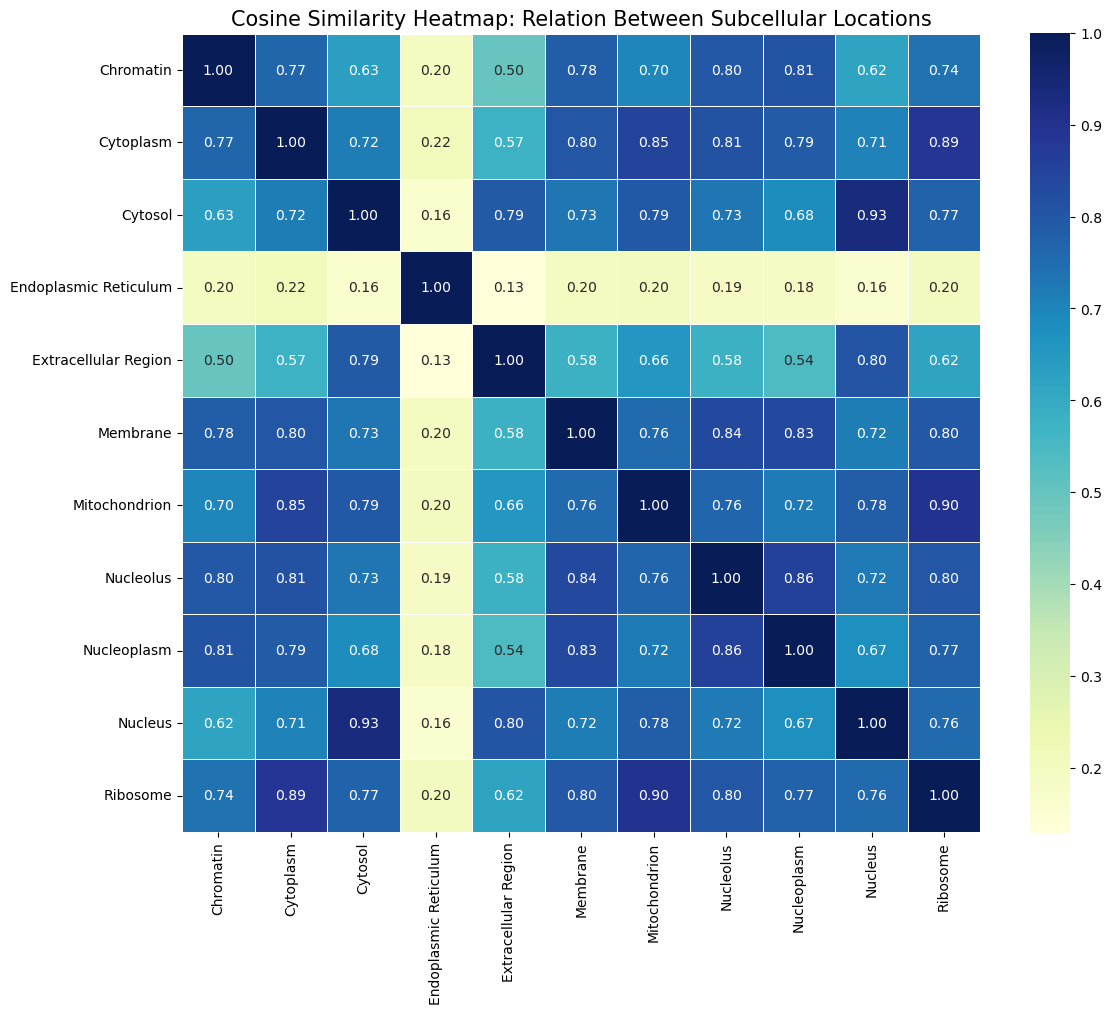

In [4]:
file_path = 'Data/Main/Probabilities.csv'
df = pd.read_csv(file_path)

prob_cols = [col for col in df.columns if col.endswith('_prob')]
prob_data = df[prob_cols]

# Calculate Cosine Similarity
# transpose the data so to compare columns (classes) instead of rows (transcripts)
cos_sim_matrix = cosine_similarity(prob_data.T)

# Format for visualization
clean_names = [col.replace('_prob', '').replace('_', ' ').title() for col in prob_cols]
cos_sim_df = pd.DataFrame(cos_sim_matrix, index=clean_names, columns=clean_names)

# Plot Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    cos_sim_df, 
    annot=True, 
    cmap='YlGnBu', 
    fmt=".2f", 
    linewidths=0.5,
    square=True
)

plt.title('Cosine Similarity Heatmap: Relation Between Subcellular Locations', fontsize=15)
plt.tight_layout()
plt.show()

### Scatter Plot

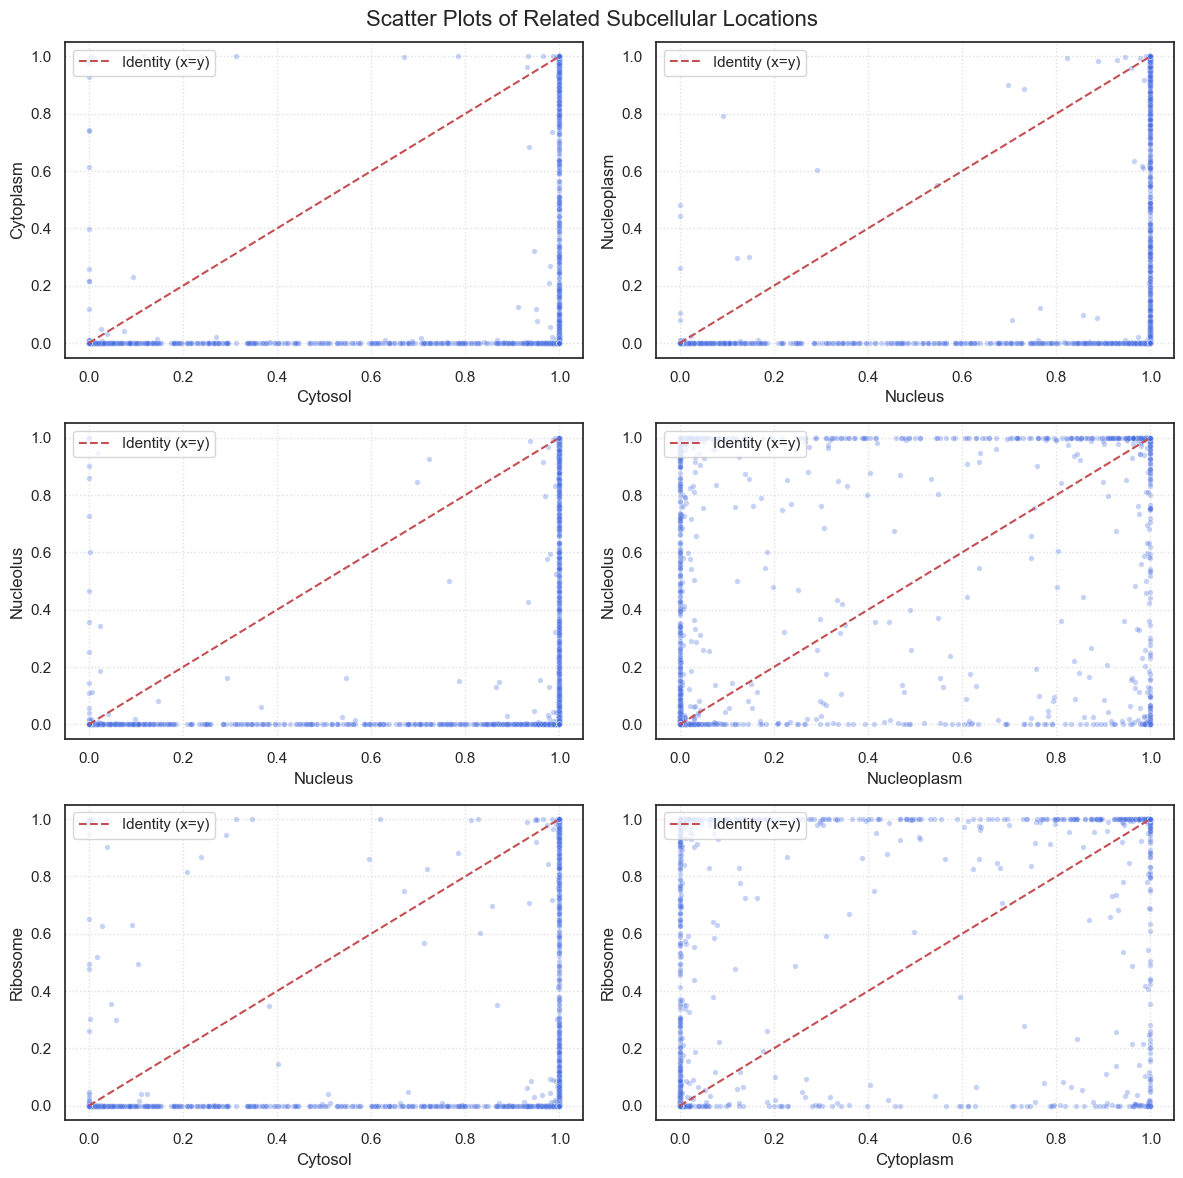

In [10]:
file_path = 'Data/Main/Probabilities.csv'
df = pd.read_csv(file_path)

# Define the pairs of columns to compare
pairs = [
    ('cytosol_prob', 'cytoplasm_prob'),
    ('nucleus_prob', 'nucleoplasm_prob'),
    ('nucleus_prob', 'nucleolus_prob'),
    ('nucleoplasm_prob', 'nucleolus_prob'),
    ('cytosol_prob', 'ribosome_prob'),
    ('cytoplasm_prob', 'ribosome_prob')
]

# Create the figure with 2x2 subplots
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

# Loop through the pairs and plot them
for i, (col1, col2) in enumerate(pairs):
    # Scatter plot with transparency (alpha) to see density
    sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.3, s=15, color='royalblue')
    
    # Add a diagonal red dashed line (x=y) for reference
    # Points on this line mean the probabilities are identical
    axes[i].plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Identity (x=y)')
    
    # Formatting
    # axes[i].set_title(f'{col1} vs {col2}', fontsize=12)
    axes[i].set_xlabel(col1.replace('_prob', '').title())
    axes[i].set_ylabel(col2.replace('_prob', '').title())
    axes[i].legend(loc='upper left')
    axes[i].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Scatter Plots of Related Subcellular Locations', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Cytoplasm is everthing, cytosl is the fluid; the former should incorprate the latter; 
# Nucleus is the combination of nuceloplasm (fluid) and nucleolus (dense structure), 
# therefore should include the other two.

# plot 1 should go the other way around. the model struggle about these two classes;
# plot 5-6 shows exact the opppsite expectation. Ribosome shound be more independent 
# to cytosol and is subset of cytoplasm. Chances are the model flipped the cytosol and cytoplasm.

# plot 2-4 are intuitive.

### 3D plot

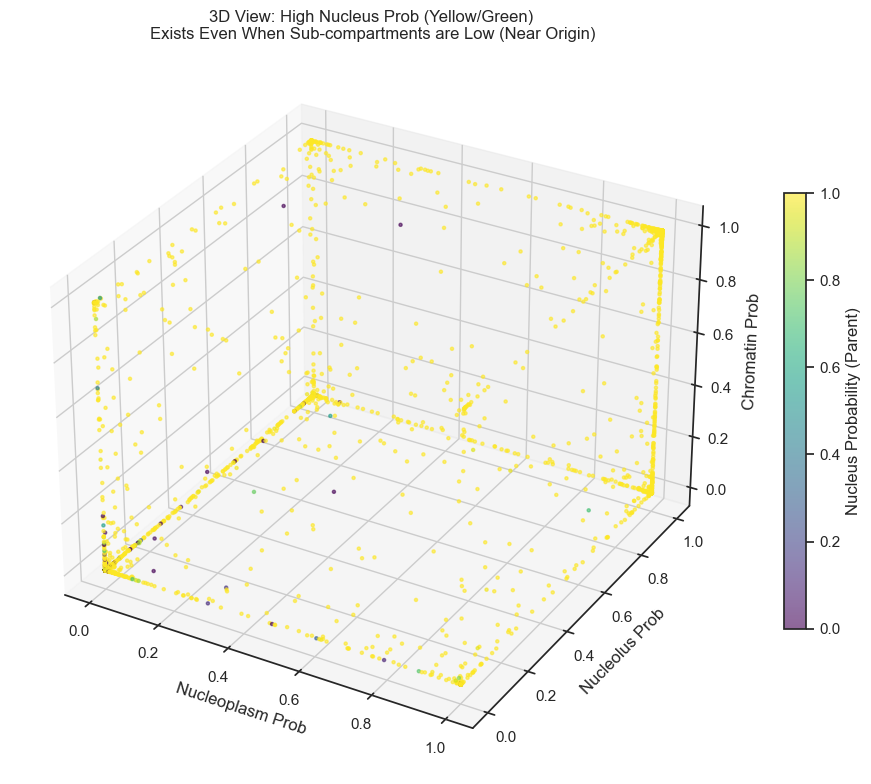

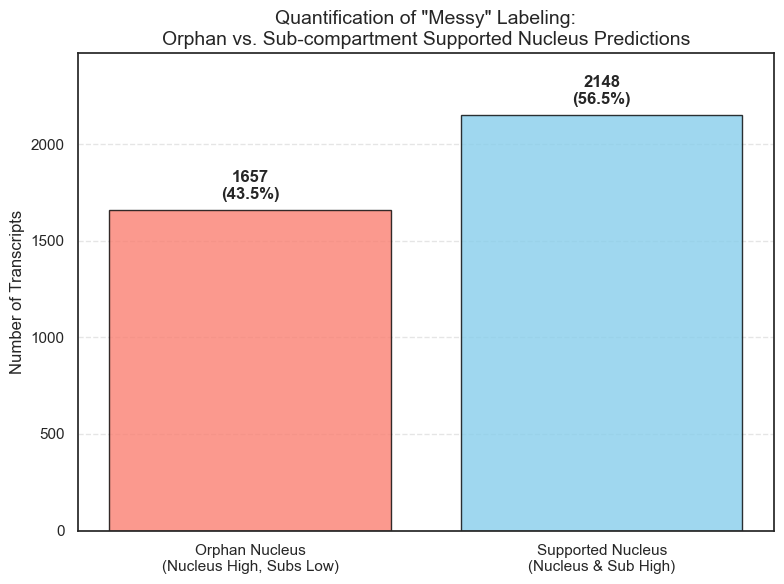

In [12]:
# Load the dataset
df = pd.read_csv('Data/Main/Probabilities.csv')

# --- 3D Scatter Plot ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot: X, Y, Z are sub-compartments, Color is Nucleus
sc = ax.scatter(df['nucleoplasm_prob'], 
                df['nucleolus_prob'], 
                df['chromatin_prob'], 
                c=df['nucleus_prob'], 
                cmap='viridis', 
                s=5, 
                alpha=0.6)

ax.set_xlabel('Nucleoplasm Prob')
ax.set_ylabel('Nucleolus Prob')
ax.set_zlabel('Chromatin Prob')
ax.set_title('3D View: High Nucleus Prob (Yellow/Green) \nExists Even When Sub-compartments are Low (Near Origin)', fontsize=12)

# Add a color bar
cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
cbar.set_label('Nucleus Probability (Parent)')

plt.tight_layout()
# plt.savefig('nucleus_3d_independence.png')
plt.show()





## --- Bar Plot --- 
# Define High Confidence Threshold
threshold = 0.5

# Identify Categories
# Nucleus is High
nucleus_high = df['nucleus_prob'] > threshold

# At least one Sub-compartment (Chromatin, Nucleolus, or Nucleoplasm) is High
sub_high = (df['chromatin_prob'] > threshold) | \
           (df['nucleolus_prob'] > threshold) | \
           (df['nucleoplasm_prob'] > threshold)

# Orphan when Nucleus is High, but ALL Sub-compartments are Low
orphan_count = (nucleus_high & ~sub_high).sum()

# Supported when Nucleus is High, and AT LEAST ONE Sub-compartment is High
supported_count = (nucleus_high & sub_high).sum()

# Prepare Data for Plotting
counts = [orphan_count, supported_count]
labels = ['Orphan Nucleus\n(Nucleus High, Subs Low)', 'Supported Nucleus\n(Nucleus & Sub High)']
colors = ['salmon', 'skyblue']

# Generate Bar Plot
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, counts, color=colors, edgecolor='black', alpha=0.8)

for bar in bars:
    height = bar.get_height()
    percentage = height / sum(counts) * 100
    plt.text(bar.get_x() + bar.get_width()/2., height + (max(counts)*0.02),
             f'{height}\n({percentage:.1f}%)',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# Formatting
plt.title('Quantification of "Messy" Labeling:\nOrphan vs. Sub-compartment Supported Nucleus Predictions', fontsize=14)
plt.ylabel('Number of Transcripts', fontsize=12)
plt.ylim(0, max(counts) * 1.15)  # Add some headroom for the text
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Save and Show
# plt.savefig('orphan_quantification_bar.png', dpi=300)
plt.show()

In [ ]:
# if the transcript is in nucleus, it's either in chromtin, nucleolus or nucleoplasm. 
# However, many nucleus are excusive or orphan, which means that the labeling was extreme messy. 
# The model still partly think the nucleus is dependent from others.